In [6]:
import os
os.chdir("/home/bluefox/NN/NN-Project3")

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
history = pd.read_csv("results/tables/training_history.csv")
history.head()

,accuracy,f1_score,loss,val_accuracy,val_f1_score,val_loss,learning_rate
0,0.306925,0.301597,1.884659,0.4032,0.366022,1.617913,0.001
1,0.434950,0.429347,1.552701,0.4994,0.463511,1.405436,0.001
2,0.493050,0.488801,1.410629,0.4985,0.447694,1.451264,0.001
3,0.527550,0.524011,1.314664,0.5659,0.539229,1.260239,0.001
4,0.564875,0.561994,1.233154,0.5964,0.576225,1.127895,0.001


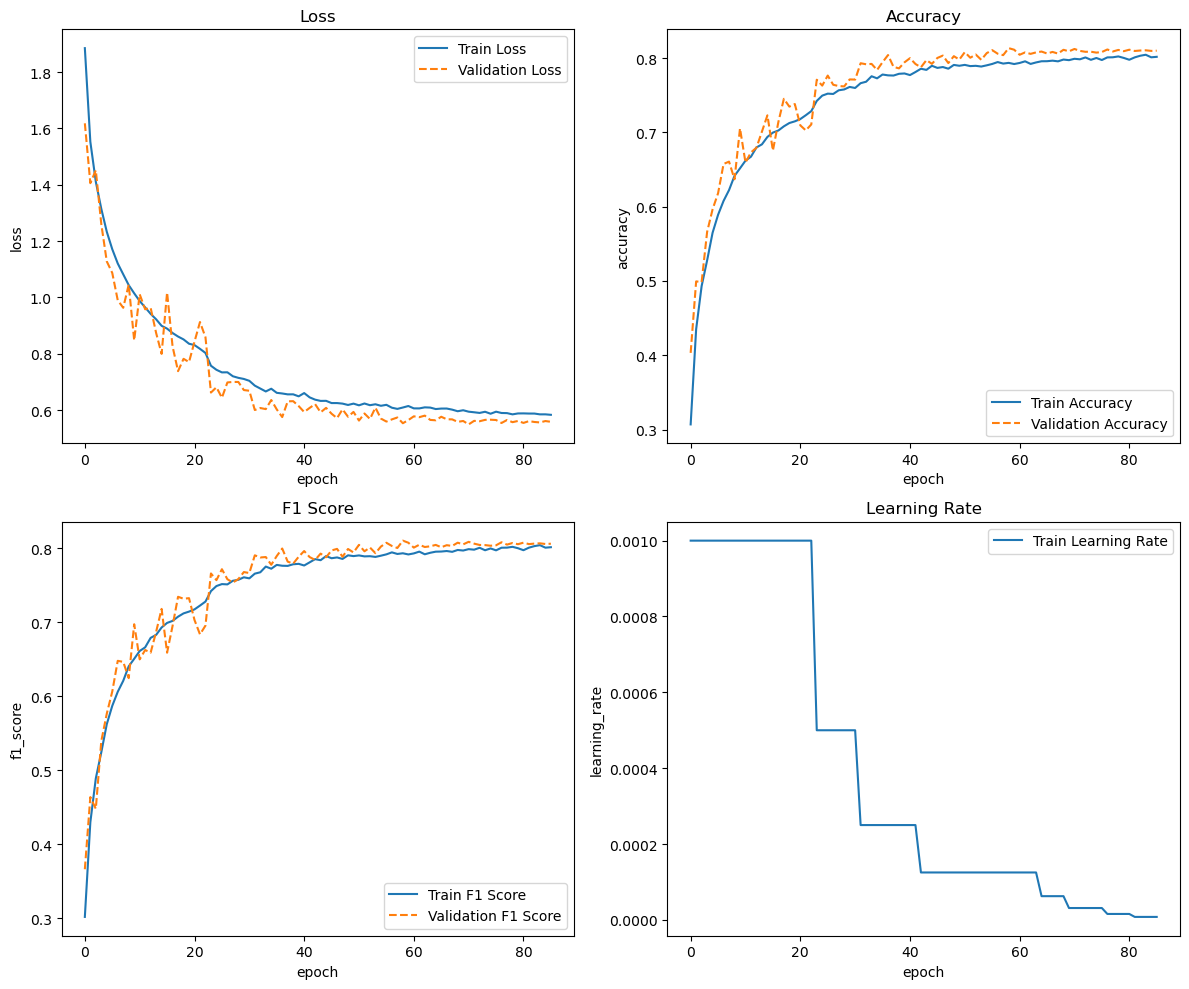

In [35]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
history["epoch"] = history.index
sns.lineplot(data=history,x="epoch", y="loss", ax=ax[0, 0], label="Train Loss",color="C0", linestyle="-")
sns.lineplot(data=history, x="epoch", y="val_loss", ax=ax[0, 0], label="Validation Loss", color="C1", linestyle="--")
ax[0, 0].set_title("Loss")
ax[0, 0].legend()
sns.lineplot(data=history, x="epoch", y="accuracy", ax=ax[0, 1], label="Train Accuracy", color="C0", linestyle="-")
sns.lineplot(data=history, x="epoch", y="val_accuracy", ax=ax[0, 1], label="Validation Accuracy", color="C1", linestyle="--")
ax[0, 1].set_title("Accuracy")
ax[0, 1].legend()
sns.lineplot(data=history, x="epoch", y="f1_score", ax=ax[1, 0], label="Train F1 Score", color="C0", linestyle="-")
sns.lineplot(data=history, x="epoch", y="val_f1_score", ax=ax[1, 0], label="Validation F1 Score", color="C1", linestyle="--")
ax[1, 0].set_title("F1 Score")
ax[1, 0].legend()
sns.lineplot(data=history, x="epoch", y="learning_rate", ax=ax[1, 1], label="Train Learning Rate", color="C0", linestyle="-")
ax[1, 1].set_title("Learning Rate")
ax[1, 1].legend()
plt.tight_layout()
plt.show()

In [36]:
import keras
model = keras.models.load_model("results/models/final_cifar10_model.keras")

2026-05-16 21:09:44.928828: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-16 21:09:44.968390: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-16 21:09:46.801363: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-16 21:09:53.171511: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [37]:
!python scripts/data.py

2026-05-16 21:10:42.944889: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-16 21:10:42.945503: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-16 21:10:43.064493: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-16 21:10:46.544029: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [40]:
import pickle
(x_test,y_test) = pickle.load(open("data/processed/test_data.pkl", "rb"))
y_test = np.argmax(y_test, axis=1)

In [41]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step


In [42]:
y_pred = np.argmax(y_pred, axis=1)

In [43]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1000
           1       0.89      0.93      0.91      1000
           2       0.84      0.70      0.76      1000
           3       0.77      0.57      0.65      1000
           4       0.82      0.74      0.78      1000
           5       0.81      0.68      0.74      1000
           6       0.68      0.94      0.79      1000
           7       0.82      0.89      0.85      1000
           8       0.91      0.88      0.89      1000
           9       0.77      0.93      0.84      1000

    accuracy                           0.81     10000
   macro avg       0.82      0.81      0.81     10000
weighted avg       0.82      0.81      0.81     10000



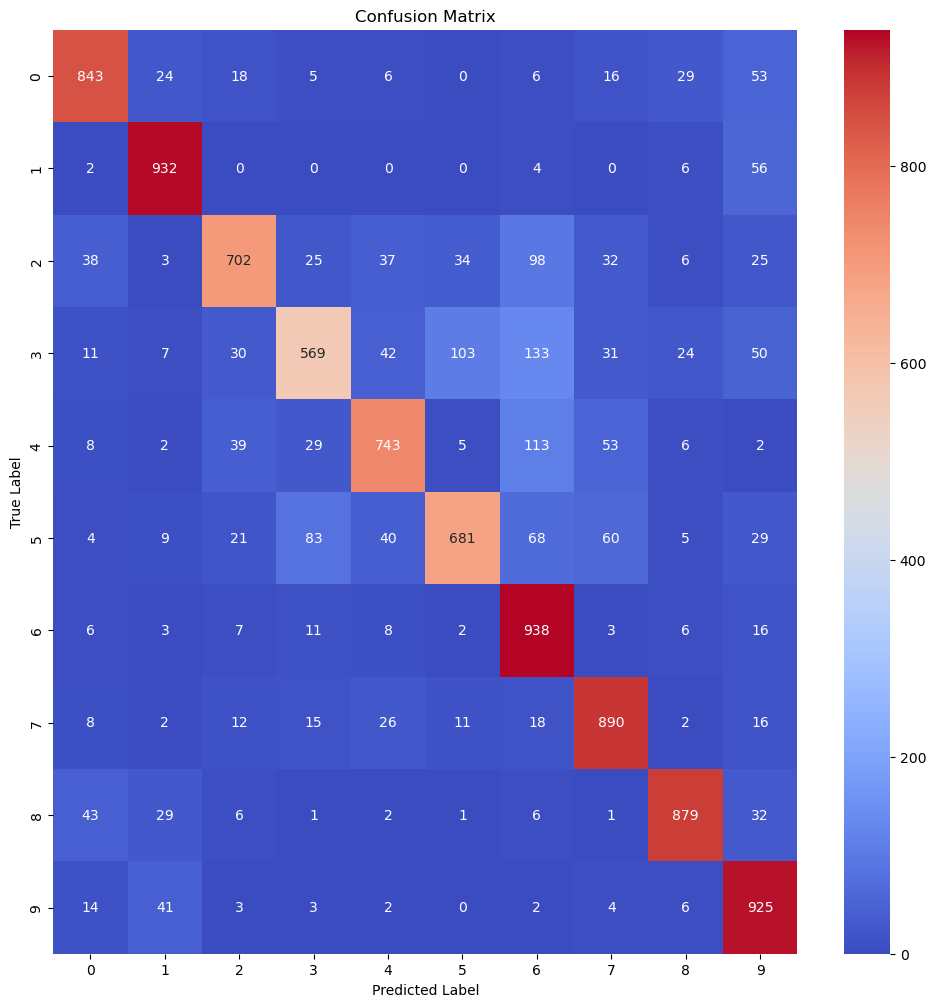

In [45]:
plt.figure(figsize=(12,12))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="coolwarm")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()